<a href="https://colab.research.google.com/github/ERAEstudianteUB2026/UBPhD-Machine-Learning2026/blob/main/Taller_1MLS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TALLER PRÁCTICO 1** semana 2  
#REGRESIÓN LINEAL PARA PREDICCIÓN DE PRECIOS DE VIVIENDAS

# Nombre y Apellido: <u>**Emiliano Rodriguez Arango**

# Descripción del dataset

El archivo contiene las siguientes variables:

| Variable | Descripción | Tipo |
|----------|-------------|------|
| **tamaño** | Tamaño de la vivienda en metros cuadrados (m²) | Numérica continua |
| **precio** | Precio de la vivienda en pesos colombianos (COP) | Numérica continua |

## Características adicionales

- El dataset contiene **valores faltantes (`NaN`)** en algunas celdas.
- La relación entre **tamaño** y **precio** es aproximadamente **lineal**, con cierto nivel de **ruido aleatorio**.

# Importar paquetes y cargar datos

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [147]:
url="https://storage.googleapis.com/backet_doctorado_ueb_2026_2/datos_viviendas_faltantes.csv"
df=pd.read_csv(url)
df.head()

,tamano,precio
0,NaN,532530.0
1,143.8,351732.0
2,179.1,526522.0
3,218.5,565288.0
4,139.5,382380.0


In [148]:
df_original = df.copy()
df_trabajo = df.copy()

In [149]:
#Ver columnas  y registros
df_trabajo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tamano  90000 non-null  float64
 1   precio  95000 non-null  float64
dtypes: float64(2)
memory usage: 1.5 MB


In [150]:
#Identificar la presencia de valores nulos.
df_trabajo.isnull().sum()

,0
tamano,10000
precio,5000


In [151]:
#Calcule estadísticas descriptivas básicas (media, mediana, desviación estándar, etc.) para ambas variables.
#clacular las estad´siticas decriptivas omitiendo valores nulos
def estadisticas(df):
    for i in df_trabajo.columns:
        print(i)
        # Omitir valores nulos (NaN)
        media = round(df[i].mean(skipna=True),2)
        mediana = round(df[i].median(skipna=True),2)
        desviacion_estandar = round(df[i].std(skipna=True),2)
        cuartiles = round(df[i].quantile([0.25, 0.5, 0.75]),2)
        maximo = round(df[i].max(skipna=True),2)
        minimo = round(df[i].min(skipna=True),2)
        print("maximo:", maximo)
        print("minimo:", minimo)
        print("cuartiles:", cuartiles)
        print("media:", media)
        print("mediana:", mediana)
        print("desviacion estandar:", desviacion_estandar)
        print()

estadisticas(df_trabajo)

tamano
maximo: 351.6
minimo: 30.0
cuartiles: 0.25    119.6
0.50    150.1
0.75    180.4
Name: tamano, dtype: float64
media: 150.07
mediana: 150.1
desviacion estandar: 44.91

precio
maximo: 1002767.0
minimo: 30000.0
cuartiles: 0.25    342106.75
0.50    425243.50
0.75    508401.25
Name: precio, dtype: float64
media: 425238.13
mediana: 425243.5
desviacion estandar: 123138.41



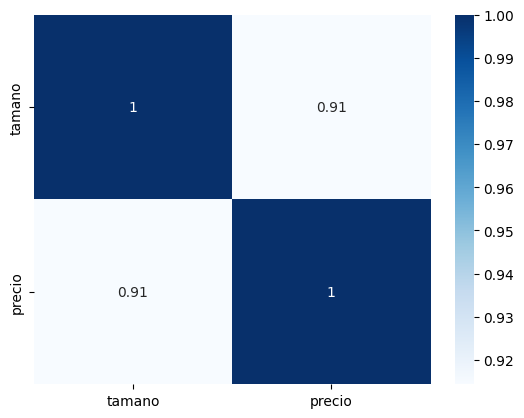

In [153]:
# Miramos correlacion entre varibles
#GRAFICAR LA matriz de correlación
#agregamos valores a las cledas de la matriz
import seaborn as sns
import matplotlib.pyplot as plt
corr = df_trabajo.corr()
sns.heatmap(corr, annot=True,cmap="Blues")

plt.show()


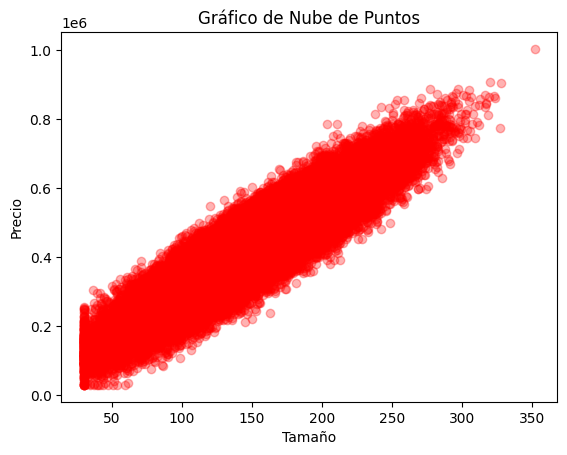

In [154]:
# Gráfico de nube de puntos

plt.scatter(df_trabajo['tamano'], df_trabajo['precio'],
            color='red',alpha=0.3)

plt.xlabel('Tamaño')
plt.ylabel('Precio')
plt.title('Gráfico de Nube de Puntos')

plt.show()


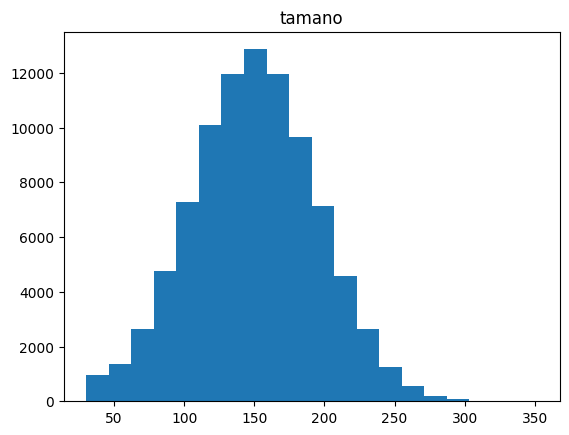

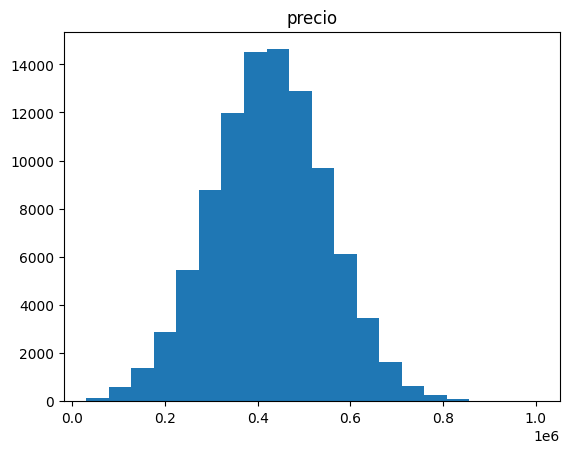

In [155]:
#Histrograma de cada variable
for i in df_trabajo.columns:
    plt.hist(df[i], bins=20)
    plt.title(i)
    plt.show()



# Tratamiento de datos faltantes (imputación)

- Identifique qué porcentaje de datos faltantes tiene cada columna.
- Seleccione una estrategia de imputación adecuada (ej. media, mediana,
eliminación de filas, etc.) y
- justifique su elección.
- Aplique la imputación para obtener un dataset completo y limpio.

### Selección de la estrategia de imputación

A partir del gráfico de dispersión se observa una fuerte relación positiva
entre las variables `tamano` y `precio`.

Por esta razón, se seleccionó el método **KNN Imputer** en lugar de la
imputación por la media. KNN permite utilizar la información de observaciones
similares para estimar los valores faltantes, aprovechando la relación
existente entre las variables.

La imputación por la media, por el contrario, asignaría el mismo valor a
todas las observaciones faltantes, sin considerar dicha relación.


KNN busca las 5 observaciones más cercanas a un NaN usando las variables disponibles, y claculo su promedio.

In [156]:
# Identificar valores faltantes por columna

nulos = df_trabajo.isnull().sum()
print(f"La variable tamano tiene {nulos['tamano']} valores nulos")
print(f"La variable precio tiene {nulos['precio']} valores nulos")

La variable tamano tiene 10000 valores nulos
La variable precio tiene 5000 valores nulos


In [176]:
# Porcentaje de valores faltantes por columna
porcen_nulos= df_trabajo.isnull().sum()/df_trabajo.shape[0]
porcentaje_nulos= 100*porcen_nulos

print(f"porcentaje nulos var tamaño: {porcentaje_nulos['tamano']}%")
print(f"porcentaje nulos var  precio: {porcentaje_nulos['precio']}%")

porcentaje nulos var tamaño: 10.0%
porcentaje nulos var  precio: 5.0%


In [157]:
# Vamos escalar los datos
def trans_formar(df):

    for i in df_trabajo.columns:

        df_trabajo[i] = (
            (df_trabajo[i] - df_trabajo[i].mean()) /
            df_trabajo[i].std()
        )

    return df_trabajo


df_scalados = trans_formar(df_trabajo)

df_scalados.head()


,tamano,precio
0,NaN,0.871311
1,-0.139676,-0.596939
2,0.646316,0.822521
3,1.523600,1.137337
4,-0.235421,-0.348048


In [158]:
#estrategia de imputación
from sklearn.impute import KNNImputer

# Crear el imputador
imputador = KNNImputer(n_neighbors=5)
# Imputar los valores faltantes
df_imputados = imputador.fit_transform(df_scalados)

In [159]:
# convertimos datos imputados en dataframe
df_imputa=pd.DataFrame(df_imputados,columns=df.columns)
df_imputa.head()

,tamano,precio
0,1.002574,0.871311
1,-0.139676,-0.596939
2,0.646316,0.822521
3,1.523600,1.137337
4,-0.235421,-0.348048


# Construcción del modelo de regresión lineal

Vamos a consturir el modelo de regresión lineal


In [160]:
import numpy as np
#Seperamos X y y
X=df_imputa.drop(columns=['precio']).to_numpy()
y=df_imputa['precio'].to_numpy()

In [161]:
X

array([[ 1.00257364],
       [-0.13967643],
       [ 0.64631631],
       ...,
       [ 0.40806922],
       [-0.2131545 ],
       [ 0.11861014]])

In [162]:
y

array([ 0.87131118, -0.59693912,  0.82252055, ...,  0.43660521,
        0.15264018, -0.32471698])

In [163]:
#Divir los datos en entrenamiento , validación y prueba
# 80% entrenamiento - 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.2)

In [164]:
#Pasamos a entrena una regresion lineal
from sklearn.linear_model import LinearRegression
LinearR = LinearRegression()
LinearR.fit(X_train, y_train)

LinearRegression()

### Desescalamiento de los datos

Para facilitar la interpretación de las métricas de evaluación, se devolverán los valores de la variable `precio` a su escala original.

Debido a que el modelo fue entrenado utilizando variables estandarizadas, las predicciones obtenidas también se encuentran en dicha escala.

La transformación inversa está dada por:

$$
x = z\sigma + \mu
$$

donde:

- $z$ es el valor estandarizado.
- $\mu$ es la media de la variable original.
- $\sigma$ es la desviación estándar de la variable original.
- $x$ es el valor recuperado en su escala original.

De esta manera, métricas como el **RMSE** podrán interpretarse directamente en pesos colombianos y el **MAPE** como un porcentaje de error sobre los precios reales.

In [165]:
#Calcular el y_pred(predicciones)
y_pred = LinearR.predict(X_test)

In [166]:
# Desescalar y_test para volver a precios en COP
y_test_original = (
    y_test * df_original['precio'].std()
    + df_original['precio'].mean()
)

# Desescalar X_test para volver a tamaño en m²
X_test_original = (
    X_test * df_original['tamano'].std()
    + df_original['tamano'].mean()
)

In [167]:
# Recuperar las predicciones en la escala original de precio
y_pred_original = (
    y_pred * df_original['precio'].std()
    + df_original['precio'].mean()
)



In [168]:
#Verificar los cambios
print(y_pred[:5])
print(y_pred_original[:5])

[-0.67804653 -1.88059906 -0.90104735 -0.49427735  0.29861442]
[341744.56254532 193664.1631262  314284.59836733 364373.60709941
 462009.03528785]


In [179]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import numpy as np
r2=round(r2_score(y_test_original,y_pred_original),4)#Esto permite clauclar el R cuadrado
rmse=round(np.sqrt(mean_squared_error(y_test_original,y_pred_original)),3)   #Esto permite calcular el erro cuadratico medio
mape=round(mean_absolute_percentage_error(y_test_original,y_pred_original)*100,3)#Esto permite calcular el error porcentual ansoliuto medio
print(f"R cuadrado:{r2*100}% de la variabilidad de la variable precio es explicada por el modelo")
print(f'RMSE:,{rmse}esto quier decir que :Las predicciones del modelo  presentan un error típico de aproximadamente {rmse}$ COP respecto a los precios reales.')
print(f'MAPE:",{mape}, En promedio, las predicciones del modelo se desvían aproximadamente un $1%%$ de los precios reales.')

R cuadrado:85.04% de la variabilidad de la variable precio es explicada por el modelo
RMSE:,47066.14esto quier decir que :Las predicciones del modelo  presentan un error típico de aproximadamente 47066.14$ COP respecto a los precios reales.
MAPE:",9.992, En promedio, las predicciones del modelo se desvían aproximadamente un $1%%$ de los precios reales.


# Predicciones interactivas.

-  Utilice el modelo entrenado para predecir el precio estimado.

- Muestre el resultado en pantalla con un formato claro, por ejemplo:

- Test:
     
     - Vivienda de 150 m² → Precio estimado: $425,000 COP

In [170]:
# predicicion intreactiva
tamano = float(input("Ingrese el tamaño de la vivienda en m²: "))
#Scalar el precio
x=(tamano-df_original['tamano'].mean())/df_original['tamano'].std()
#Predecir
precio_estimado = LinearR.predict([[x]])
#recuperamos el precio al original
precio=precio_estimado[0]*df_original['precio'].std()+df_original['precio'].mean()
print(f"Vivienda de {tamano} m² → Precio estimado: ${precio:,.0f} COP")

Ingrese el tamaño de la vivienda en m²: 150
Vivienda de 150.0 m² → Precio estimado: $425,141 COP


# Visualización de resultados
- Genere un gráfico de dispersión que muestre los datos reales (tamaño vs precio) y superponga la línea de regresión.

- Opcionalmente, puede incluir un gráfico de residuos para evaluar el
comportamiento del error.

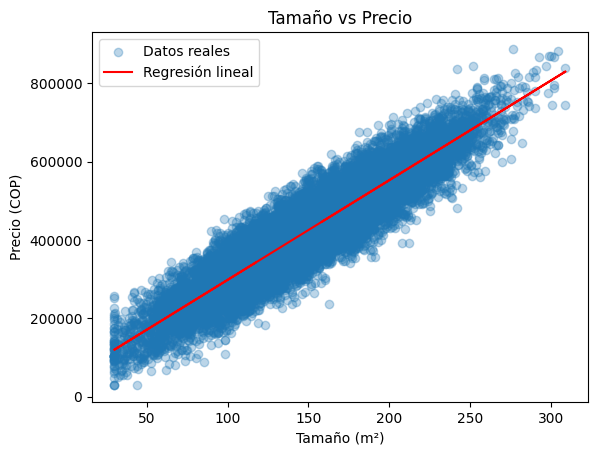

In [171]:
import matplotlib.pyplot as plt

# Graficamos los precios reales
plt.scatter(
    X_test_original[:, 0],
    y_test_original,
    alpha=0.3,
    label='Datos reales'
)

# Graficamos la línea de regresión
plt.plot(
    X_test_original[:, 0],
    y_pred_original,
    color='red',
    label='Regresión lineal'
)

# Etiquetas y título del gráfico
plt.xlabel('Tamaño (m²)')
plt.ylabel('Precio (COP)')
plt.title('Tamaño vs Precio')
plt.legend()

plt.show()

### Interpretación del gráfico

El gráfico muestra una relación positiva y aproximadamente lineal entre el
tamaño de la vivienda y su precio. A medida que aumenta el tamaño de la
vivienda, también tiende a aumentar su precio.

La línea de regresión se encuentra aproximadamente en el centro de la nube
de puntos,se observa cierta dispersión de los valores reales alrededor
de la línea de regresión.

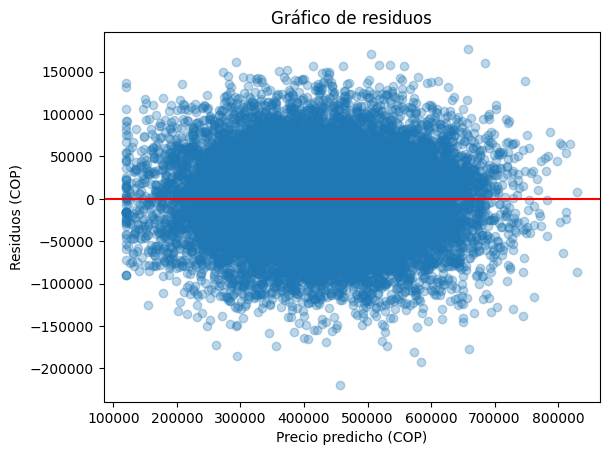

In [172]:
# Calculamos los residuos
residuos = y_test_original - y_pred_original

# Graficamos los residuos
plt.scatter(
    y_pred_original,
    residuos,
    alpha=0.3
)

# Línea horizontal en cero
plt.axhline(
    y=0,
    color='red'
)

# Etiquetas y título
plt.xlabel('Precio predicho (COP)')
plt.ylabel('Residuos (COP)')
plt.title('Gráfico de residuos')

plt.show()

### Interpretación del gráfico de residuos

El gráfico muestra que los residuos se distribuyen alrededor de cero; sin
embargo, presentan una dispersión considerable a lo largo de los valores
predichos.

Además, la amplitud de los residuos no parece completamente uniforme en
todo el rango de predicciones, lo que podría indicar que la varianza del
error no es constante.

